In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Verificar se o arquivo CSV já existe
csv_path = '/content/drive/MyDrive/WPEIF/subset.csv'
excel_path = '/content/drive/MyDrive/WPEIF/planilha_final_jogos_global.xlsx'

if not os.path.exists(csv_path):
    # Carregar o arquivo Excel e transformar em CSV
    df_subset = pd.read_excel(excel_path)
    # Salvar como CSV
    df_subset.to_csv(csv_path, index=False)
    print("Arquivo CSV gerado com sucesso.")
else:
    print("Arquivo CSV já existe. Nenhuma ação necessária.")

# Carregar os dados do CSV
df = pd.read_csv(csv_path)

# Visualizar as primeiras linhas
print("Dados carregados:")
print(df.head())


Arquivo CSV já existe. Nenhuma ação necessária.
Dados carregados:
                  Time        RTT    No.         Source    Destination  \
0  2024-07-07 22:21:46  28.203125  17182  192.168.8.134   162.249.72.5   
1  2024-07-07 22:21:47  28.500000  17297   162.249.72.5  192.168.8.134   
2  2024-07-07 22:21:48  28.000000  17591   162.249.72.5  192.168.8.134   
3  2024-07-07 22:21:49  28.089286  17620   162.249.72.5  192.168.8.134   
4  2024-07-07 22:21:50  28.187500  17709  192.168.8.134   162.249.72.5   

  Protocol  Length                    Info Country          Region  \
0      UDP     561  61162  >  7116 Len=519      GB  Greater London   
1      UDP     694  7116  >  61162 Len=652      US      California   
2      UDP      53   7116  >  61162 Len=11      US      California   
3      UDP      61   7116  >  61162 Len=19      US      California   
4      UDP      69   61162  >  7116 Len=27      GB  Greater London   

          City                     Org   Longitude   Latitude Connec

Todos Algoritmos Juntos


In [ ]:
!pip install --upgrade numpy
!pip install --upgrade catboost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Carregar os dados
df = pd.read_csv(csv_path)  # Ajuste o nome do arquivo

# Definir features e labels
X = df[['RTT', 'Length']].values  # Features
y = df['Label'].values  # Rótulos

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelos a serem testados
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DT': DecisionTreeClassifier(),
    'RF': RandomForestClassifier(n_estimators=100),
    'CatBoost': CatBoostClassifier(verbose=0)
}

# Número de iterações
n_iter = 10
final_results = {}
all_iterations = {}

for model_name, model in models.items():
    metrics_list = []
    conf_matrices = []
    print(f"\nExecutando modelo: {model_name}\n")

    for i in range(n_iter):
        # Dividir em treino e teste sem seed
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

        # Treinar o modelo
        model.fit(X_train, y_train)

        # Fazer previsões
        y_pred = model.predict(X_test)

        # Avaliar o modelo
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, output_dict=True)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if len(set(y)) == 2 else np.nan

        # Salvar métricas da iteração
        iteration_metrics = {
            'iteration': i + 1,
            'accuracy': accuracy,
            'precision': class_report['weighted avg']['precision'],
            'recall': class_report['weighted avg']['recall'],
            'f1-score': class_report['weighted avg']['f1-score'],
            'auc-roc': auc
        }
        metrics_list.append(iteration_metrics)

        # Salvar matriz de confusão
        conf_matrices.append(conf_matrix)

        # Exibir métricas da iteração
        print(f"Iteração {i + 1} - {model_name}:\n",
              f"Accuracy: {accuracy:.4f}, ",
              f"Precision: {iteration_metrics['precision']:.4f}, ",
              f"Recall: {iteration_metrics['recall']:.4f}, ",
              f"F1-score: {iteration_metrics['f1-score']:.4f}, ",
              f"AUC-ROC: {iteration_metrics['auc-roc']:.4f}\n")

    # Criar DataFrame de métricas
    metrics_df = pd.DataFrame(metrics_list)

    # Salvar todas as execuções para o modelo
    all_iterations[model_name] = metrics_df
    metrics_df.to_csv(f"{model_name}_all_iterations.csv", index=False)

    # Calcular média das métricas apenas no final
    final_metrics = metrics_df.mean()
    print(f"Média das métricas para {model_name} após 10 execuções:")
    print(final_metrics)

    # Calcular matriz de confusão média
    if conf_matrices:
        avg_conf_matrix = np.mean(np.array(conf_matrices), axis=0)
        avg_conf_matrix = np.rint(avg_conf_matrix).astype(int)
        print(f"Matriz de Confusão Média para {model_name}:")
        print(avg_conf_matrix)
        pd.DataFrame(avg_conf_matrix).to_csv(f"{model_name}_avg_conf_matrix.csv", index=False)

    # Salvar métricas finais
    final_results[model_name] = final_metrics

# Salvar todas as métricas médias em CSV
final_results_df = pd.DataFrame(final_results).T
final_results_df.to_csv("models_metrics_summary.csv", index=True)

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
 

ValueError: multiclass format is not supported


LSTM


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Carregar os dados
df = pd.read_csv(csv_path)

# Mapear os rótulos para valores numéricos
label_mapping = {'LOL': 0, 'TFT': 1, 'VAL': 2}
df['Label'] = df['Label'].map(label_mapping)

# Definir features e labels
X = df[['RTT', 'Length']].values
y = df['Label'].values

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Número de iterações
n_iter = 10
final_results = {}
all_iterations = {}

# LSTM
print("\nExecutando modelo: LSTM\n")
lstm_metrics_list = []
for i in range(n_iter):
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
    X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    y_train_cat = to_categorical(y_train, num_classes=3)
    y_test_cat = to_categorical(y_test, num_classes=3)

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_lstm).argmax(axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    iteration_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'precision': class_report['weighted avg']['precision'],
        'recall': class_report['weighted avg']['recall'],
        'f1-score': class_report['weighted avg']['f1-score']
    }
    lstm_metrics_list.append(iteration_metrics)

    print(f"Iteração {i + 1} - LSTM:\n",
          f"Accuracy: {accuracy:.4f}, ",
          f"Precision: {iteration_metrics['precision']:.4f}, ",
          f"Recall: {iteration_metrics['recall']:.4f}, ",
          f"F1-score: {iteration_metrics['f1-score']:.4f}\n")

lstm_metrics_df = pd.DataFrame(lstm_metrics_list)
lstm_metrics_df.to_csv("LSTM_all_iterations.csv", index=False)
final_results['LSTM'] = lstm_metrics_df.mean()
final_results_df = pd.DataFrame(final_results).T
final_results_df.to_csv("models_metrics_summary.csv", index=True)



Executando modelo: LSTM



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Iteração 1 - LSTM:
 Accuracy: 0.9183,  Precision: 0.9209,  Recall: 0.9183,  F1-score: 0.9192



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Iteração 2 - LSTM:
 Accuracy: 0.9147,  Precision: 0.9141,  Recall: 0.9147,  F1-score: 0.9139



...

434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteração 8 - LSTM:
 Accuracy: 0.9055,  Precision: 0.9063,  Recall: 0.9055,  F1-score: 0.9039



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Iteração 9 - LSTM:
 Accuracy: 0.9235,  Precision: 0.9220,  Recall: 0.9235,  F1-score: 0.9223



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Iteração 10 - LSTM:
 Accuracy: 0.8904,  Precision: 0.8920,  Recall: 0.8904,  F1-score: 0.8876



ROC Curve e Precision Recall Catboost


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, accuracy_score, classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from catboost import CatBoostClassifier
from matplotlib.backends.backend_pdf import PdfPages

# 🚀 Carregar os dados
df = pd.read_csv(csv_path)

# 🚀 Definir features e labels
X = df[['RTT', 'Length']].values  # Features
y = df['Label'].values  # Rótulos (certifique-se de que são categóricos)

# 🚀 Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🚀 Binarizar as labels para problemas multiclasse (necessário para Curva ROC e Precision-Recall)
y_binarized = label_binarize(y, classes=np.unique(y))
n_classes = y_binarized.shape[1]  # Número de classes

# 🚀 Criar modelo CatBoost com One-vs-Rest
catboost_model = OneVsRestClassifier(CatBoostClassifier(verbose=0))

# 🚀 Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binarized, test_size=0.2, random_state=42)

# 🚀 Treinar o modelo
catboost_model.fit(X_train, y_train)

# 🚀 Fazer previsões
y_pred = catboost_model.predict(X_test)
y_scores = catboost_model.predict_proba(X_test)

# 🚀 Avaliação geral do modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))

print(f"\n📊 Acurácia do modelo: {accuracy:.4f}")
print("\n📄 Relatório de Classificação:\n", report)
print("\n🔍 Matriz de Confusão:\n", conf_matrix)

# 🚀 Criar e salvar as curvas ROC e Precision-Recall em PDFs separados
for i in range(n_classes):
    roc_pdf_filename = f"ROC_Curve_Class_{i}.pdf"
    pr_pdf_filename = f"Precision_Recall_Curve_Class_{i}.pdf"

    # 🔹 Curva ROC
    fpr, tpr, _ = roc_curve(y_test[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)

    with PdfPages(roc_pdf_filename) as pdf:
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color='blue')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - Classe {i}")
        plt.legend(loc="lower right")
        pdf.savefig()
        plt.close()
    print(f"✅ Curva ROC salva como {roc_pdf_filename}")

    # 🔹 Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_scores[:, i])

    with PdfPages(pr_pdf_filename) as pdf:
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label="Precision-Recall Curve", color='red')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve - Classe {i}")
        plt.legend(loc="lower left")
        pdf.savefig()
        plt.close()
    print(f"✅ Curva Precision-Recall salva como {pr_pdf_filename}")


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 Acurácia do modelo: 0.9426

📄 Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7727
           1       0.91      0.84      0.87      2885
           2       0.97      0.98      0.98      3267

   micro avg       0.95      0.95      0.95     13879
   macro avg       0.95      0.93      0.94     13879
weighted avg       0.95      0.95      0.95     13879
 samples avg       0.94      0.95      0.95     13879


🔍 Matriz de Confusão:
 [[7560  152   15]
 [ 413 2405   67]
 [  15   59 3193]]
✅ Curva ROC salva como ROC_Curve_Class_0.pdf
✅ Curva Precision-Recall salva como Precision_Recall_Curve_Class_0.pdf
✅ Curva ROC salva como ROC_Curve_Class_1.pdf
✅ Curva Precision-Recall salva como Precision_Recall_Curve_Class_1.pdf
✅ Curva ROC salva como ROC_Curve_Class_2.pdf
✅ Curva Precision-Recall salva como Precision_Recall_Curve_Class_2.pdf


RTT Distribuition


<ipython-input-26-a074d6654f44>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='RTT', palette='Set3')


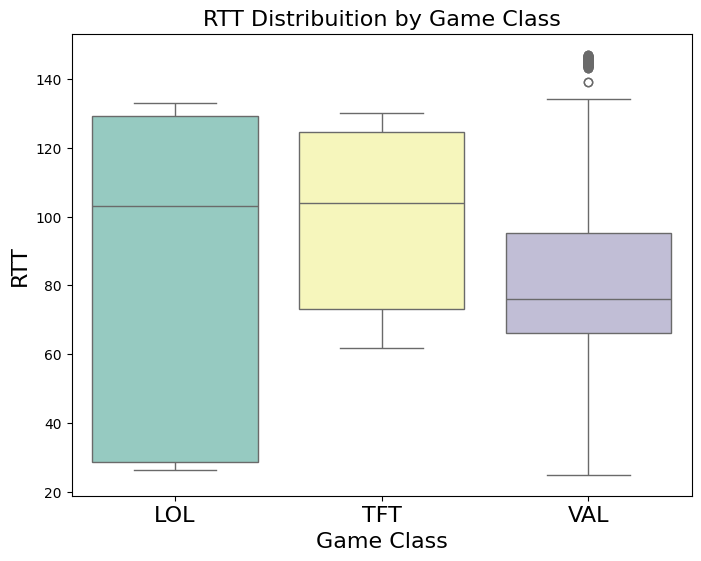

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv(csv_path)

# Mapear os rótulos para valores numéricos
label_mapping = {'LOL': 0, 'TFT': 1, 'VAL': 2}
df['Label'] = df['Label'].map(label_mapping)

# Plotando o Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Label', y='RTT', palette='Set3')

# Definir rótulos com fonte maior
plt.title('RTT Distribuition by Game Class', fontsize=16)
plt.xlabel('Game Class', fontsize=16)
plt.ylabel('RTT', fontsize=16)

# Ajustar os rótulos da classe para nome das categorias
plt.xticks([0, 1, 2], ['LOL', 'TFT', 'VAL'], fontsize=16)

# Salvar o gráfico como PDF
plt.savefig("/content/drive/MyDrive/WPEIF/RTT_Distribution_by_Game_Class.pdf", format='pdf')

# Exibir o gráfico
plt.show()



Games Distribuition

<ipython-input-25-46450271295e>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='Set3')


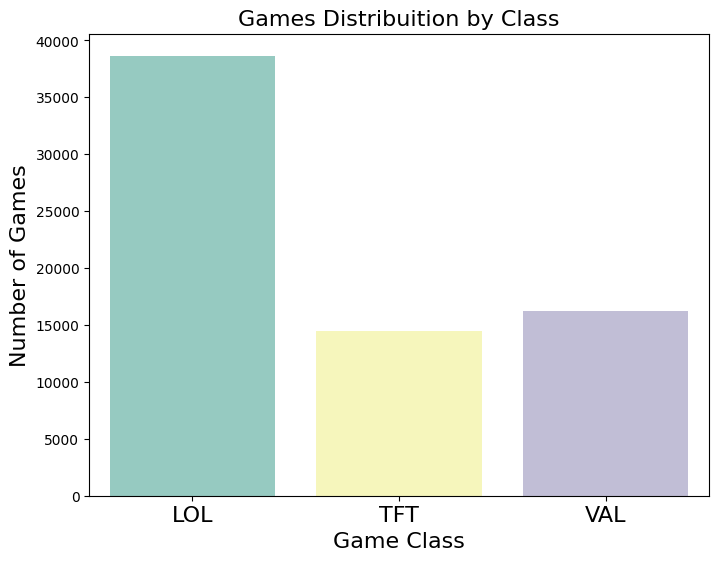

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv(csv_path)

# Mapear os rótulos para valores numéricos
label_mapping = {'LOL': 0, 'TFT': 1, 'VAL': 2}
df['Label'] = df['Label'].map(label_mapping)

# Plotando o gráfico de barras
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Label', palette='Set3')

# Definir rótulos com fonte maior
plt.title('Games Distribuition by Class', fontsize=16)
plt.xlabel('Game Class', fontsize=16)
plt.ylabel('Number of Games', fontsize=16)

# Ajustar os rótulos da classe para nome das categorias
plt.xticks([0, 1, 2], ['LOL', 'TFT', 'VAL'], fontsize=16)

# Salvar o gráfico como PDF
plt.savefig('/content/drive/MyDrive/WPEIF/games_distribution_by_class.pdf', format='pdf')

# Exibir o gráfico
plt.show()


Latency Distribuition

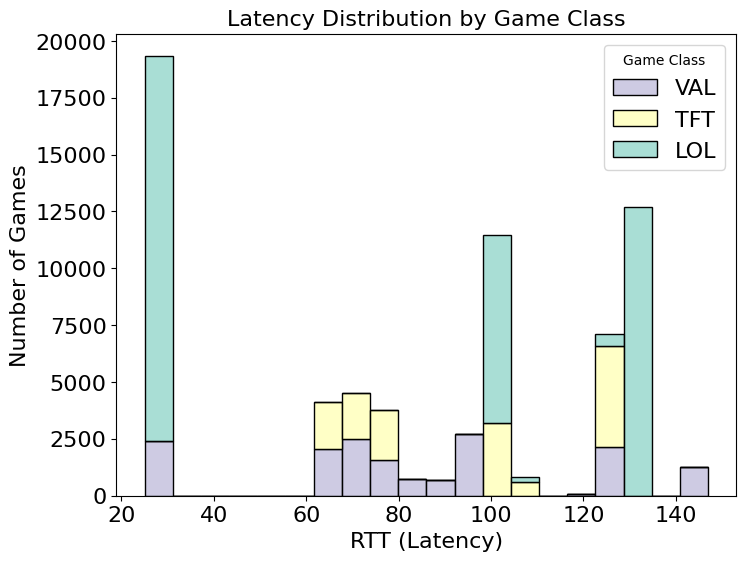

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv(csv_path)

# Mapear os rótulos para valores numéricos
label_mapping = {'LOL': 0, 'TFT': 1, 'VAL': 2}
df['Label'] = df['Label'].map(label_mapping)

# Plotando o histograma
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='RTT', hue='Label', multiple='stack', palette='Set3', bins=20)

# Definir rótulos com fonte maior
plt.title('Latency Distribution by Game Class', fontsize=16)
plt.xlabel('RTT (Latency)', fontsize=16)
plt.ylabel('Number of Games', fontsize=16)

# Ajustar os rótulos da classe para nome das categorias
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Atualizar a legenda para mostrar os nomes das classes
plt.legend(title='Game Class', labels=['VAL', 'TFT', 'LOL'], fontsize=16)

# Salvar o gráfico como PDF
plt.savefig('/content/drive/MyDrive/WPEIF/latency_distribuition_by_gameclass.pdf', format='pdf')


# Exibir o gráfico
plt.show()

intervalo de confiaça

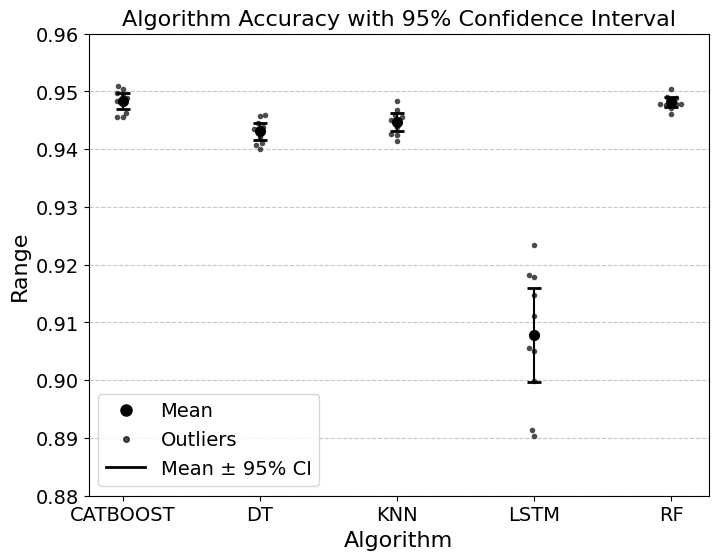

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Dados
data = {
    "Algorithm": ["CATBOOST"] * 10 + ["DT"] * 10 + ["KNN"] * 10 + ["LSTM"] * 10 + ["RF"] * 10,
    "Accuracy": [
        0.9504, 0.9497, 0.9488, 0.9509, 0.9483, 0.9455, 0.9483, 0.9455, 0.9463, 0.9493,
        0.9457, 0.9435, 0.9460, 0.9431, 0.9400, 0.9411, 0.9439, 0.9421, 0.9445, 0.9408,
        0.9450, 0.9468, 0.9424, 0.9414, 0.9459, 0.9439, 0.9427, 0.9455, 0.9450, 0.9483,
        0.9183, 0.9147, 0.8913, 0.9050, 0.9112, 0.8999, 0.9179, 0.9055, 0.9235, 0.8904,
        0.9505, 0.9483, 0.9478, 0.9477, 0.9491, 0.9478, 0.9479, 0.9488, 0.9472, 0.9461
    ]
}

df = pd.DataFrame(data)

# Calcular a média e o intervalo de confiança (95%) para cada algoritmo
summary = df.groupby("Algorithm")["Accuracy"].agg(["mean", "std", "count"])
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = summary["sem"] * stats.t.ppf((1 + 0.95) / 2., summary["count"] - 1)

# Criar figura
plt.figure(figsize=(8, 6))

# Plotar os pontos individuais
sns.swarmplot(x="Algorithm", y="Accuracy", data=df, color="black", size=4, alpha=0.7)

# Adicionar pontos médios
sns.pointplot(
    x=summary.index,
    y=summary["mean"],
    linestyle="none",  # Substitui `join=False`
    color="black",
    markers="o",
    markersize=6,  # Em vez de `scale=1.5`
    errorbar=None  # Substitui `ci=None`
)

# Adicionar barras de erro
for i, (mean, ci) in enumerate(zip(summary["mean"], summary["ci95"])):
    plt.errorbar(i, mean, yerr=ci, fmt='none', ecolor='black', capsize=5, capthick=2)

# Melhorar a legenda e o layout
plt.xlabel("Algorithm",fontsize=16)
plt.ylabel("Range",fontsize=16)
plt.title("Algorithm Accuracy with 95% Confidence Interval",fontsize=16)
plt.ylim(0.88, 0.96)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Criar legenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='black', markersize=8, linestyle='None', label='Mean'),
    Line2D([0], [0], marker='o', color='black', markersize=4, linestyle='None', alpha=0.7, label='Outliers'),
    Line2D([0], [0], color='black', lw=2, label='Mean ± 95% CI')
]
plt.legend(handles=legend_elements, loc='lower left',fontsize=14)

# Salvar o gráfico como PDF
plt.savefig('/content/drive/MyDrive/WPEIF/acuracy_confidence_interval.pdf', format='pdf')


# Exibir gráfico
plt.show()
